# Foundations of Machine learning

Problem Set 4

Emily Fu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys  
import os
from pathlib import Path

# importing my code from another file
import importlib
sys.path.insert(0, str(Path.cwd()))

import functions_A4
from functions_A4 import bernoulli_bandit_thompson, calculate_replication, evaluate_bandit

# set seed
seed = np.random.seed(420)

In this problem, you are asked to simulate data for a Bernoulli bandit problem, where $D_t \in \{1,...,k\}$, $Yt = Y^{D}_t$ , $Y^{d}_t ∼ \text{Ber}( \theta_{d} )$ and treatment is assigned using Thompson sampling with a uniform prior, $(\theta_{1},...,\theta_{k}) ∼ U([0,1]^k)$. Recall that Thompson sampling assigns $D_t = \text{argmax}_d \: \hat{\theta}^{d}_t$, where $\hat{\theta}_t$ is a draw from the posterior after period $t−1$.

Set up a function which accepts a sample size $T$ and a k-vector $(\theta_{1},...,\theta_{k})$ as its arguments, and returns a history $(D_t,Y_t)^T_{t=1}$ generated based on the Bernoulli bandit model and Thompson sampling

I'm writing this in the VSCode Jupyter extension and can't get parallel computing to work in its actual UI, so I've made up a Python file and am pasting the functions here as plaintext

```
def bernoulli_bandit_thompson(T, theta, seed=420):
    rng = np.random.default_rng(seed)

    # get the amount of treatments from their true expected outcomes
    k = len(theta)
    
    # initialise arrays to store the selected treatments and observed outcomes
    D_t = np.zeros(T, dtype=int)
    Y_t = np.zeros(T)
    
    # the posterior for theta_d at time t + 1 is a Beta distribution with parameters
    # start with uniform prior over theta on [0, 1]^k
    # 1 + number of successes
    alpha = np.ones(k)
    # 1 + number of failures
    beta = np.ones(k)
    
    for t in range(T):
        # sample from the Beta distribution for each arm
        samples = rng.beta(alpha, beta)
        
        # select the treatment with the highest sample
        action = np.argmax(samples)
        D_t[t] = action + 1
        
        # assume that outcome follows a Bernoulli distribution with parameter theta[action]
        outcome = rng.binomial(1, theta[action])
        Y_t[t] = outcome
        
        # update alpha and beta parameters of posterior based on the observed outcome
        if outcome:
            # another success
            alpha[action] += 1
        else:
            # not success
            beta[action] += 1
            
    return D_t, Y_t
```

Write a second function which takes the same arguments, plus a number of replications $R$, and evaluates the first function $R$ times (using parallel computing; for instance the `future` package). This function should return 4 vectors of length $T$: The averages of $Y_t$, $\theta^{D_t}$, ${1(D_t = \text{argmax}_d \: \theta_{d})}$, and $\text{max} \: \theta_{d} − \theta^{D_t} $, for each time period $t$.

Splitting this into one kind-of-lambda function and one that does the parallel computing:

```
def calculate_replication(T, theta, seed=420):
    # format of theta
    theta = np.asarray(theta, dtype=float)

    # get the actions and outcomes for T time steps
    D_t, Y_t = bernoulli_bandit_thompson(T, theta, seed=seed)

    # best treatment and its theta value
    best_arm = np.argmax(theta)
    best_theta = np.max(theta)
    
    # get the theta value of the selected arm at each time step
    theta_Dt = theta[D_t - 1]  # fix python array indexing
    optimal_indicator = (D_t - 1 == best_arm).astype(float)  # fix python array indexing
    # calculate regret at each time step
    regret_t = best_theta - theta_Dt

    return Y_t.astype(float), theta_Dt, optimal_indicator, regret_t

def evaluate_bandit(T, theta, R, seed=420):
    # format of theta
    theta = np.asarray(theta, dtype=float)

    # actually do it for the R replications
    tasks = [delayed(calculate_replication)(T, theta, seed + r) for r in range(R)]

    # compute the results in parallel using dask
    results = compute(*tasks, scheduler='threads')

    # aggregate results across replications
    Y_all = np.array([res[0] for res in results])
    thetaDt_all = np.array([res[1] for res in results])
    opt_all = np.array([res[2] for res in results])
    regret_all = np.array([res[3] for res in results])

    # averagevalues of Y_t, theta_Dt, optimal indicator, and regret_t across the R replications
    avg_Y_t = Y_all.mean(axis=0)
    avg_theta_Dt = thetaDt_all.mean(axis=0)
    avg_optimal = opt_all.mean(axis=0)
    avg_regret_t = regret_all.mean(axis=0)

    return avg_Y_t, avg_theta_Dt, avg_optimal, avg_regret_t
```

Pick a fixed vector of parameters $(\theta_{1},...,\theta_{k})$ and a time horizon $T$ and use the second function to plot the average (across replications) of cumulative average regret

$$\frac{1}{T} \sum_{1 \leq t \leq T} [(\text{max}_{d} \: \theta^{d}) - \theta^{D_t}]$$

as a function of T, using a large number of replications $R$ (such as $R = 10.000$). Repeat this for several different choices of $(\theta_{1},...,\theta_{k})$

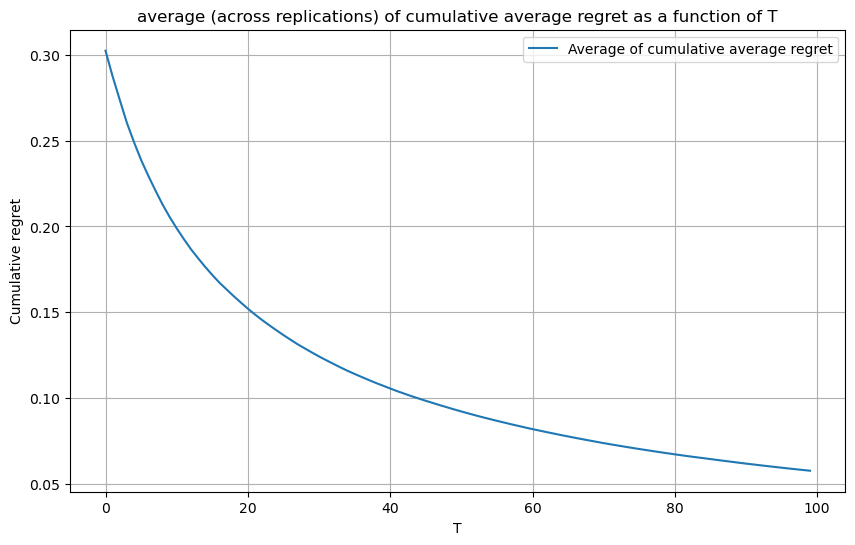

In [ ]:
theta = [0.2, 0.5, 0.8]
thetas = [[0.2, 0.5, 0.8], [0.1, 0.4, 0.9], [0.3, 0.6, 0.7], [0.9, 0.5, 0.1], [0.4, 0.8, 0.6]]
T = 100
R = 10000

avg_Y_t, avg_theta_Dt, avg_optimal, avg_regret_t, avg_cum_regret_t, avg_cumavg_regret_t = evaluate_bandit(T, theta, R)

# plot average (across replications) of cumulative average regret as a function of T
plt.figure(figsize=(10, 6))
plt.plot(avg_cumavg_regret_t, label='Average of cumulative average regret')
plt.xlabel('T')
plt.ylabel('Cumulative regret')
plt.title('average (across replications) of cumulative average regret as a function of T')
plt.legend()
plt.grid()
plt.show()


In [5]:
avg_regret_t

array([0.3069, 0.2709, 0.249 , 0.2172, 0.198 , 0.1938, 0.168 , 0.15  ,
       0.1419, 0.1377, 0.1332, 0.1344, 0.1137, 0.1101, 0.093 , 0.1083,
       0.0972, 0.0975, 0.0948, 0.0945, 0.0762, 0.0792, 0.0636, 0.0753,
       0.0651, 0.0684, 0.0612, 0.0573, 0.0582, 0.0597, 0.0513, 0.0513,
       0.0528, 0.0504, 0.0543, 0.0483, 0.0516, 0.045 , 0.0471, 0.0498,
       0.0435, 0.0381, 0.0444, 0.0444, 0.0444, 0.0354, 0.0426, 0.0387,
       0.0372, 0.0321, 0.0327, 0.0297, 0.0327, 0.0294, 0.0303, 0.0291,
       0.0303, 0.0318, 0.0267, 0.0249, 0.0255, 0.0255, 0.0252, 0.0306,
       0.0237, 0.0234, 0.0222, 0.0261, 0.0213, 0.0192, 0.0243, 0.024 ,
       0.0219, 0.0201, 0.0216, 0.0204, 0.021 , 0.0189, 0.0162, 0.0189,
       0.021 , 0.0249, 0.0207, 0.0228, 0.024 , 0.0168, 0.0195, 0.0174,
       0.0162, 0.0168, 0.0186, 0.0186, 0.0102, 0.015 , 0.0144, 0.0132,
       0.0147, 0.0186, 0.0168, 0.0135])

In [6]:
avg_Y_t

array([0.464, 0.545, 0.553, 0.59 , 0.584, 0.621, 0.607, 0.642, 0.662,
       0.656, 0.659, 0.66 , 0.673, 0.695, 0.726, 0.717, 0.709, 0.695,
       0.695, 0.722, 0.7  , 0.716, 0.732, 0.715, 0.726, 0.739, 0.723,
       0.722, 0.756, 0.742, 0.753, 0.773, 0.748, 0.761, 0.753, 0.733,
       0.73 , 0.786, 0.749, 0.742, 0.799, 0.756, 0.746, 0.753, 0.768,
       0.771, 0.748, 0.776, 0.766, 0.791, 0.761, 0.766, 0.766, 0.764,
       0.741, 0.768, 0.776, 0.732, 0.765, 0.766, 0.777, 0.807, 0.764,
       0.788, 0.788, 0.778, 0.768, 0.773, 0.787, 0.753, 0.748, 0.788,
       0.771, 0.801, 0.775, 0.766, 0.787, 0.783, 0.788, 0.794, 0.763,
       0.774, 0.763, 0.76 , 0.769, 0.804, 0.786, 0.784, 0.804, 0.787,
       0.78 , 0.767, 0.809, 0.765, 0.781, 0.771, 0.8  , 0.797, 0.791,
       0.788])